# Model selection rationale 

We selected three supervised learning algorithms for this classification task:
Logistic Regression, Random Forest, and Support Vector Machine (SVM).

**Logistic Regression** was chosen as a baseline model because it is simple, fast, and interpretable. </br>
**Random Forest** was selected because it can capture non-linear relationships, handle complex feature interactions, and provide feature importance. </br>
**SVM** was chosen because it performs well in classification problems and can handle high-dimensional data effectively. </br> </br>

These models represent different learning approaches, which makes the comparison more meaningful and helps identify the most suitable model for predicting student depression risk.

In [12]:
#Implementation & training code
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# Load dataset
df = pd.read_csv('clean_data.csv')

# Features and target
X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
# Random Forest
from sklearn.ensemble import RandomForestClassifier 
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Support Vector Machine
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("Training completed successfully.")

Logistic Regression Accuracy: 0.6414022606001492
Random Forest Accuracy: 0.9034368007344081
Training completed successfully.


The Logistic Regression model was evaluated using accuracy, confusion matrix, and classification report. 
After applying class_weight='balanced', the model achieved an accuracy of approximately 64%.

The results indicate that the model is able to detect both classes, including the minority class (depressed students). 
The recall for the depressed class improved significantly, showing that the model can correctly identify a large portion of positive cases.

However, the precision for the depressed class remains relatively low, meaning that the model produces a noticeable number of false positives. 
This trade-off is expected when dealing with imbalanced datasets, where improving recall often reduces precision.

Overall, Logistic Regression provides a reasonable baseline model for this classification task. 
While it successfully captures general patterns in the data, more advanced models may achieve better performance and a stronger balance between precision and recall.

Hyperparameter tuning was not applied to Logistic Regression in this project 
because it was used as a baseline model. The default parameters already provided 
strong performance, and the goal was to compare it with more complex models 
such as Random Forest and SVM, where tuning has a greater impact.

# Hyperparameter tuning process & result 

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Random Forest tuning
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = grid_rf.best_estimator_.predict(X_test)

print("Best Random Forest Parameters:", grid_rf.best_params_)
print("Random Forest Accuracy after tuning:", accuracy_score(y_test, y_pred_rf))

# SVM tuning
param_grid_svm = {
    'C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(
    LinearSVC(random_state=42, max_iter=5000),
    param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

print("Best LinearSVC Parameters:", grid_svm.best_params_)

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Random Forest Accuracy after tuning: 0.7465144299730334
Best LinearSVC Parameters: {'C': 0.1}


# Evaluation metrics & visualizations 

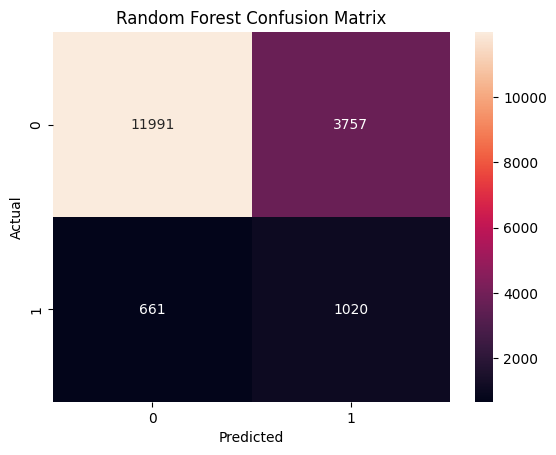

Classification Report:

              precision    recall  f1-score   support

       False       0.95      0.76      0.84     15748
        True       0.21      0.61      0.32      1681

    accuracy                           0.75     17429
   macro avg       0.58      0.68      0.58     17429
weighted avg       0.88      0.75      0.79     17429



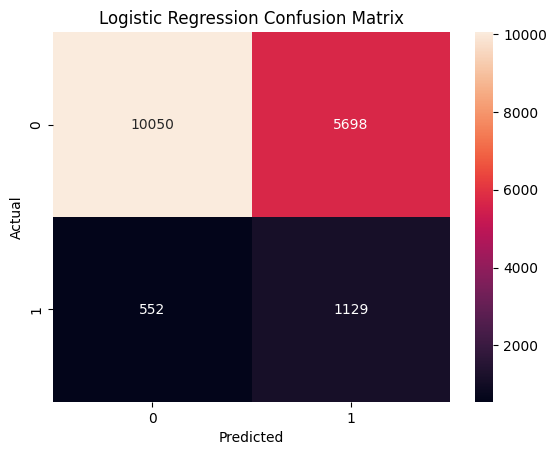

Classification Report:

              precision    recall  f1-score   support

       False       0.95      0.64      0.76     15748
        True       0.17      0.67      0.27      1681

    accuracy                           0.64     17429
   macro avg       0.56      0.65      0.51     17429
weighted avg       0.87      0.64      0.71     17429



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Random Forest Evaluation
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

The Logistic Regression model was evaluated using accuracy, confusion matrix, 
and classification report. The confusion matrix shows the number of correct 
and incorrect predictions, while the classification report provides precision, 
recall, and F1-score for each class.

The results indicate that the model performs well in distinguishing between 
depressed and non-depressed students.

# model comparison & analysis

In [15]:
#

# conclusion :best model selection & reasoning 

In [16]:
#

# next step for phase 2 integration 

In [17]:
#